In [2]:
# import numpy as np
# lats=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats.npy")
# lons=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons.npy")

# x=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/xc_21.npy")
# y2=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/y2c_21.npy")
# y=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]
# nanindex=np.where(np.isnan(y[:,205]))
# x=np.delete(x,nanindex,axis=0)
# y=np.delete(y,nanindex,axis=0)
# y2=np.delete(y2,nanindex,axis=0)
# lats=np.delete(lats,nanindex,axis=0)
# lons=np.delete(lons,nanindex,axis=0)

# s0=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/566/eg_30_eval.npy")
# s1=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567/eg_30_eval.npy")
# s2=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/568/eg_30_eval.npy")
# s3=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/569/eg_30_eval-1.npy")

# slist=[s0,s1,s2,s3]
# varlist=["LAI","SST","TA","SSDR","BDOD","SAND","SILT","CLAY"]

# std_mean_m_variables=np.full((733, 8), np.nan)
# for i in range(8):
#     xais_np_m = np.full((733, 4, 216, 21, 21), np.nan)
#     for k in range(4):
#         xais_np_m[:, k, :, :, :] = slist[k][:, i, :, :, :]
#     std_np_m = np.std(xais_np_m, axis=1)
#     std_mean_m = np.nanmean(np.nanmean(np.nanmean(std_np_m, axis=-1), axis=-1), axis=-1)
#     std_mean_m_variables[:,i]=std_mean_m
# np.save('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/std_randomseeds.npy',std_mean_m_variables)

In [5]:
import numpy as np
import ultraplot as uplt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes
from affine import Affine
from rasterio.features import rasterize
import xarray as xr
import cartopy.feature as cfeature
from numpy import ma 
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D
import pandas as pd
import rioxarray
import matplotlib.pyplot as plt

uplt.rc.style='seaborn-v0_8-paper'
uplt.rc.update({'tick.len': 2.0, 'tick.dir': 'in', 'font.largesize': 12, 'font.smallsize': 10})
lonlim = (-82, -32)
latlim = (-60, 15)

amazon_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/amazonia_polygons.shp"
amazon_vector = gpd.read_file(amazon_shapefile)
#amazon_vector = amazon_vector[amazon_vector['name'] == 'Amazonia - sensu stricto'].dissolve()
amazon_vector = amazon_vector.dissolve()
amazon_border = amazon_vector.loc[[0]]

geography_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/ne_10m_geography_regions_polys.shp"
geography_vector = gpd.read_file(geography_shapefile)


In [4]:
def get_da(arr):
    lats=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats_737.npy")
    lons=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons_737.npy")
    df_pivot= pd.DataFrame({'values': arr,'lat': lats, 'lon': lons}).pivot_table(index='lat',columns='lon',values='values')
    da= xr.DataArray(df_pivot,dims=('lat', 'lon'), coords={'lat': df_pivot.index, 'lon': df_pivot.columns})
    return da

In [6]:
std_mean_m_variables=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/std_randomseeds.npy',)

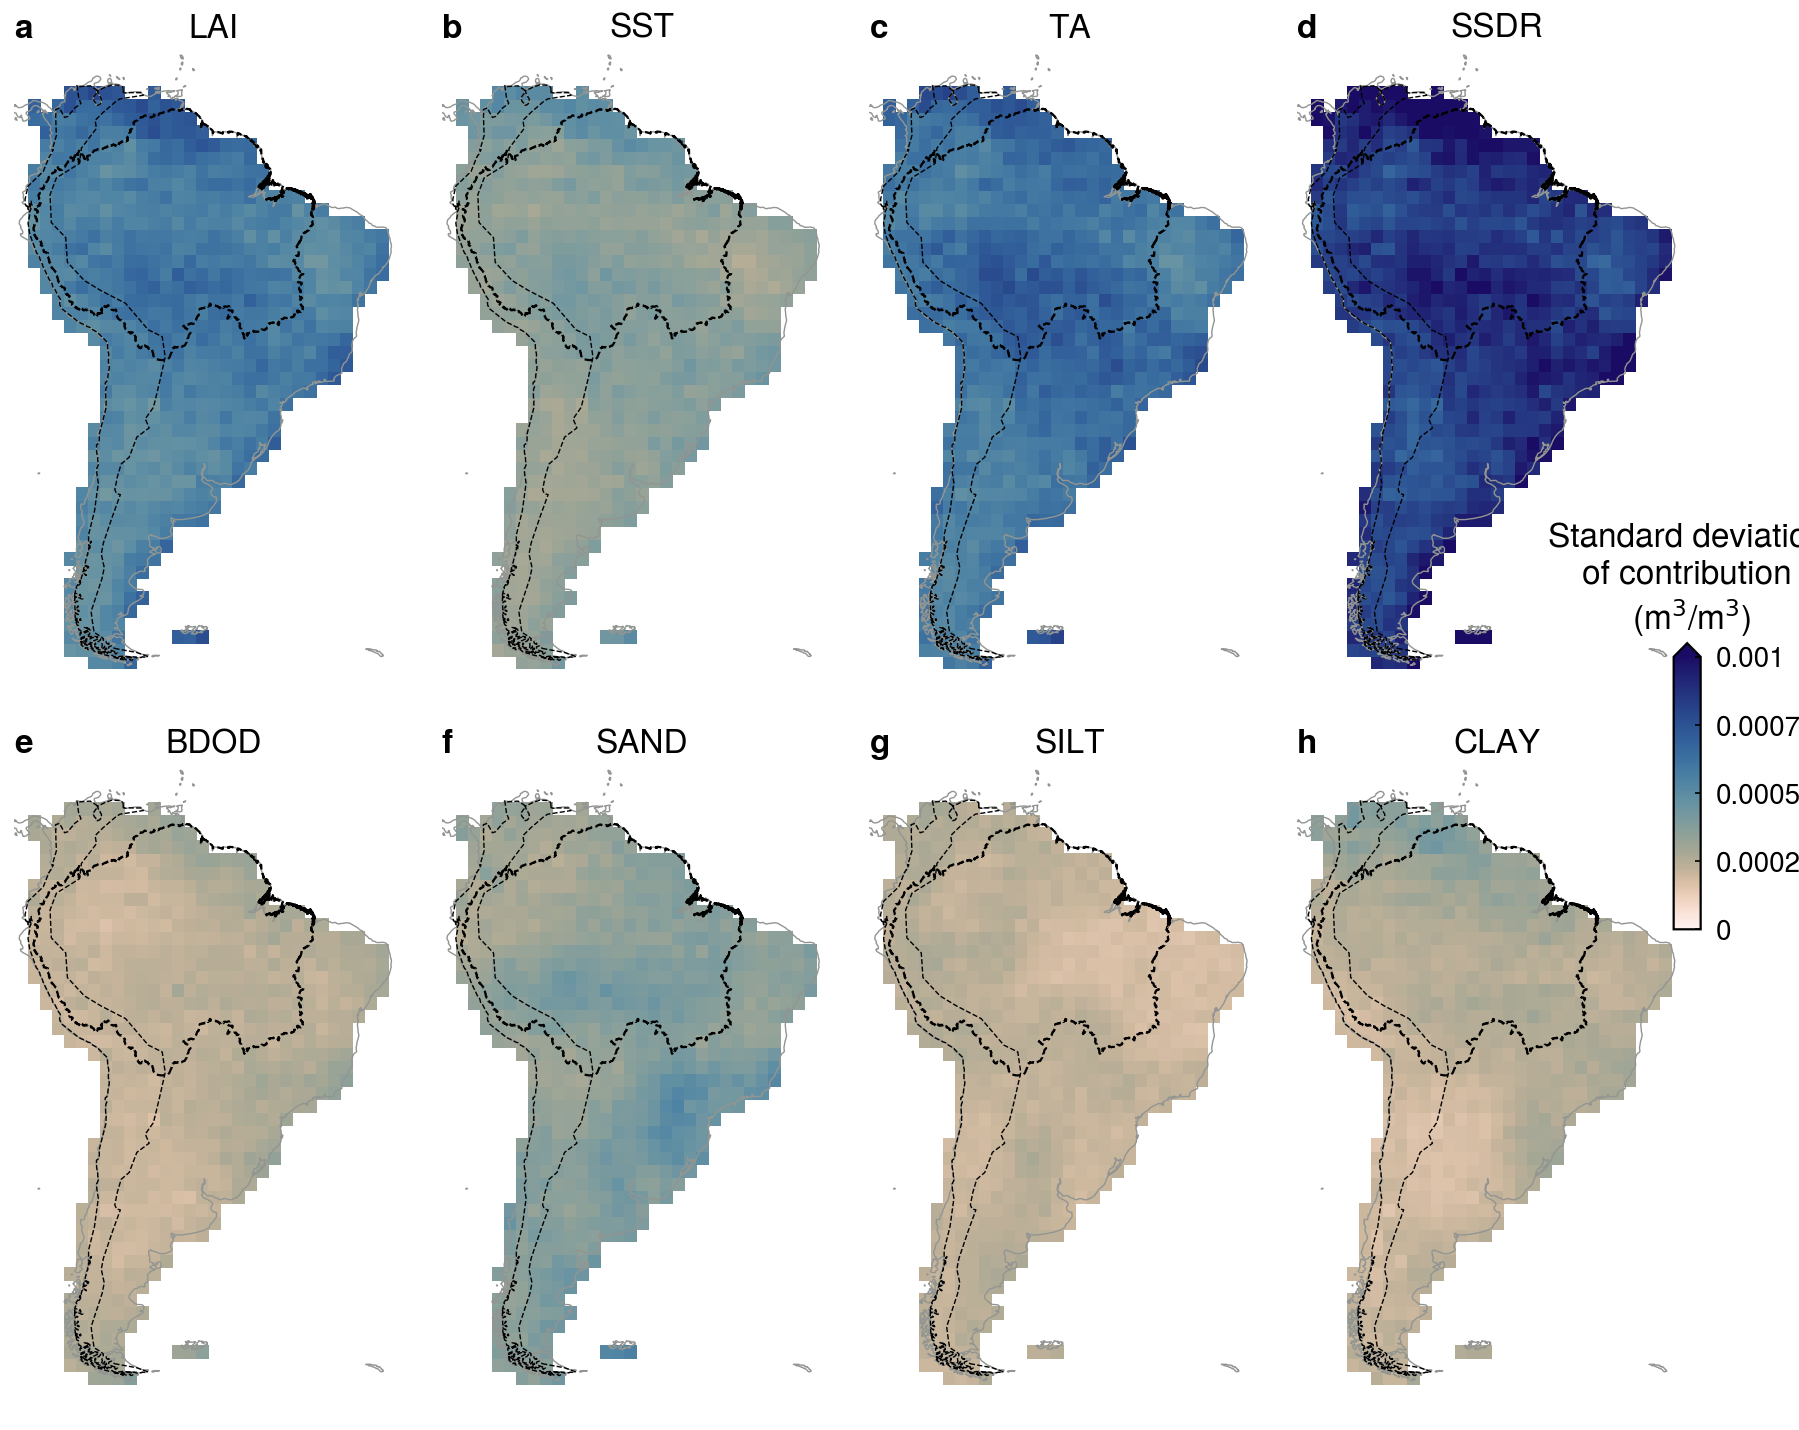

In [19]:
proj = ccrs.PlateCarree()

arrray = [  # the "picture" (0 == nothing, 1 == subplot A, 2 == subplot B, etc.)
    [1, 2, 3, 4],
    [5, 6, 7, 8],
]
fig = uplt.figure(refwidth=2, share=False, span=False, tight=True)
axs = fig.subplots(arrray, projection=proj, abc=True, width_ratios=[1, 1, 1,1], height_ratios=[1, 1])
axs.format(lonlim=lonlim, latlim=latlim, linewidth=0)

varlist=["LAI","SST","TA","SSDR","BDOD","SAND","SILT","CLAY"]

for i in range(8):
    ax = axs[i]
    da=get_da(arr=std_mean_m_variables[:,i])
    im = ax.pcolormesh(
        da.lon,
        da.lat,
        da.values,
        cmap='lapaz_r',
        discrete=False,
        transform=ccrs.PlateCarree(),
        vmin=-0.003, vmax=0.003,
    )
    
    amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
    geography_vector[geography_vector['NAME']=='ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
    ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)
    ax.set_title(varlist[i])

cax = fig.add_axes([0.93, 0.35, 0.015, 0.2], title='Standard deviation\nof contribution\n (m$^3$/m$^3$)')
fig.colorbar(
    im,
    cax=cax,
    orientation='vertical',
    extend='max',
    ticks=[0.,0.00025, 0.0005,0.00075, 0.001],
)
